<a href="https://colab.research.google.com/github/michaelespin15-code/archaeological-anomaly-detector/blob/main/Archaelogical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install earthengine-api geemap rasterio geopandas folium matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.5 MB/s eta 0:00:00


In [3]:
import ee
import geemap

ee.Authenticate()

In [4]:
ee.Initialize(project='email-proj-491903')
print("Earth Engine connected.")

Earth Engine connected.


In [5]:
region = ee.Geometry.Rectangle([-75.5, -8.5, -74.5, -7.5])

Map = geemap.Map()
Map.centerObject(region, 9)
Map.addLayer(region, {}, 'Target Region')
Map

Map(center=[-8.00009622440674, -74.99999999999993], controls=(WidgetControl(options=['position', 'transparent_…

In [6]:
# input only the bands we need before compositing
bands_needed = ['B2', 'B3', 'B4', 'B8']

image = (ee.ImageCollection('COPERNICUS/S2_SR')
    .filterBounds(region)
    .filterDate('2023-01-01', '2024-06-01')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .select(bands_needed)
    .median()
    .clip(region))

vis_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000,
    'gamma': 1.4
}

print("Image loaded successfully.")

Image loaded successfully.


In [7]:
nir = image.select('B8')
red = image.select('B4')

ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')

ndvi_vis = {
    'min': -0.2,
    'max': 0.9,
    'palette': ['brown', 'yellow', 'green']
}

Map.addLayer(ndvi, ndvi_vis, 'NDVI')
Map

Map(center=[-8.00009622440674, -74.99999999999993], controls=(WidgetControl(options=['position', 'transparent_…

Total pixels sampled: 49284
Min z-score: -2.00
Max z-score: 2.00
Pixels flagged (abs > 2.5): 0


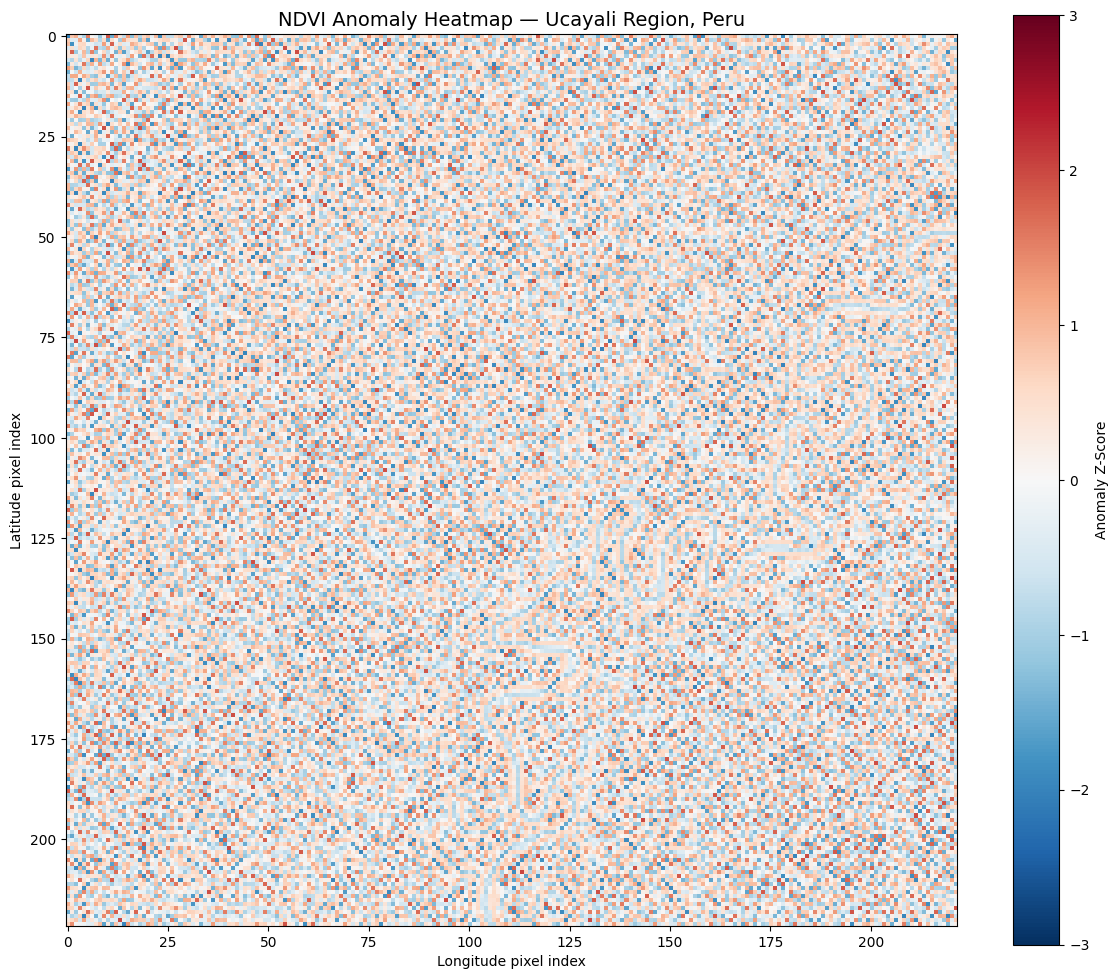

Done. Saved as anomaly_heatmap.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# recompute
ndvi_mean = ndvi.focal_mean(radius=500, units='meters', kernelType='circle')

ndvi_std = ndvi.reduceNeighborhood(
    reducer=ee.Reducer.stdDev(),
    kernel=ee.Kernel.circle(radius=500, units='meters')
).rename('std')

z_score = ndvi.subtract(ndvi_mean).divide(ndvi_std).rename('anomaly_score')

# sample at lower scale so we get a real grid of pixels
sample = z_score.reduceRegion(
    reducer=ee.Reducer.toList(),
    geometry=region,
    scale=500,
    maxPixels=1e6
)

z_list = sample.get('anomaly_score').getInfo()
print(f"Total pixels sampled: {len(z_list)}")
print(f"Min z-score: {min(z_list):.2f}")
print(f"Max z-score: {max(z_list):.2f}")
print(f"Pixels flagged (abs > 2.5): {sum(1 for z in z_list if abs(z) > 2.5)}")

# convert to 2D array for plotting
side = int(len(z_list) ** 0.5)
z_array = np.array(z_list[:side*side]).reshape(side, side)

fig, ax = plt.subplots(figsize=(12, 10))
img_plot = ax.imshow(
    z_array,
    cmap='RdBu_r',
    vmin=-3,
    vmax=3,
    interpolation='nearest'
)
plt.colorbar(img_plot, ax=ax, label='Anomaly Z-Score')
ax.set_title('NDVI Anomaly Heatmap — Ucayali Region, Peru', fontsize=14)
ax.set_xlabel('Longitude pixel index')
ax.set_ylabel('Latitude pixel index')
plt.tight_layout()
plt.savefig('anomaly_heatmap.png', dpi=150)
plt.show()
print("Done. Saved as anomaly_heatmap.png")

In [9]:
Map.centerObject(region, 10)
Map

Map(center=[-8.00009622440674, -74.99999999999993], controls=(WidgetControl(options=['position', 'transparent_…

Total pixels: 49284
Mean z-score: 0.012
Std of z-scores: 0.850
Min: -1.998
Max: 1.996
Pixels beyond 1.5σ: 3774
Pixels beyond 1.0σ: 12585
Pixels beyond 0.5σ: 30098


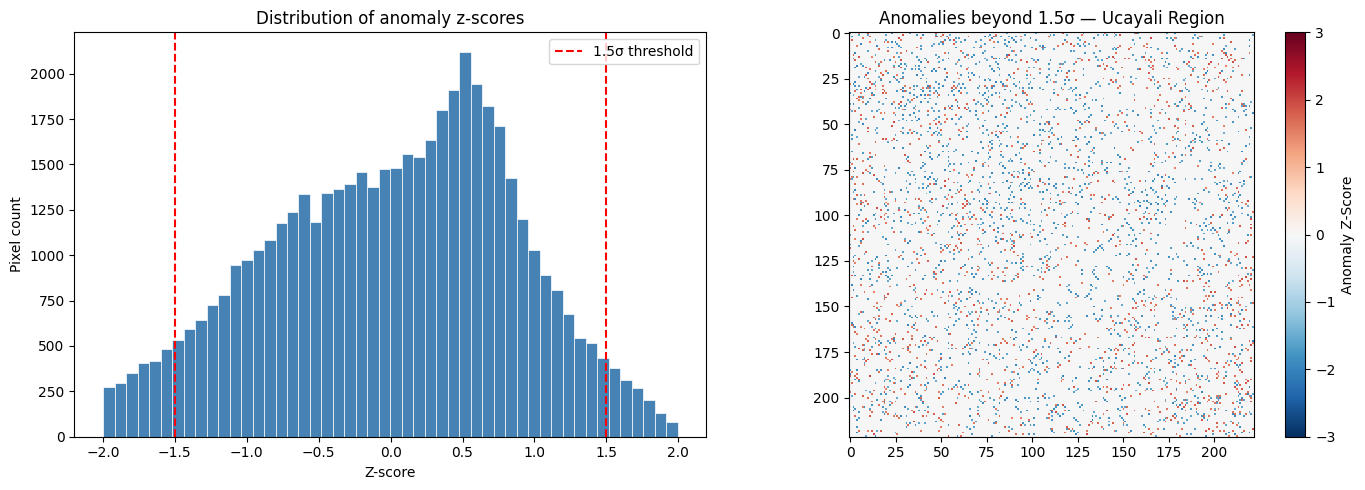

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# diagnostic
z_array_flat = np.array(z_list)

print(f"Total pixels: {len(z_array_flat)}")
print(f"Mean z-score: {z_array_flat.mean():.3f}")
print(f"Std of z-scores: {z_array_flat.std():.3f}")
print(f"Min: {z_array_flat.min():.3f}")
print(f"Max: {z_array_flat.max():.3f}")
print(f"Pixels beyond 1.5σ: {(np.abs(z_array_flat) > 1.5).sum()}")
print(f"Pixels beyond 1.0σ: {(np.abs(z_array_flat) > 1.0).sum()}")
print(f"Pixels beyond 0.5σ: {(np.abs(z_array_flat) > 0.5).sum()}")

# plot the distribution to see the shape
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# histogram of all z-scores
ax1.hist(z_array_flat, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.axvline(x=1.5, color='red', linestyle='--', label='1.5σ threshold')
ax1.axvline(x=-1.5, color='red', linestyle='--')
ax1.set_title('Distribution of anomaly z-scores')
ax1.set_xlabel('Z-score')
ax1.set_ylabel('Pixel count')
ax1.legend()

# heatmap at 1.5 threshold
threshold = 1.5
z_filtered = np.array([v if abs(v) > threshold else 0 for v in z_list[:side*side]])
z_filtered_2d = z_filtered.reshape(side, side)

img_plot = ax2.imshow(z_filtered_2d, cmap='RdBu_r', vmin=-3, vmax=3, interpolation='nearest')
plt.colorbar(img_plot, ax=ax2, label='Anomaly Z-Score')
ax2.set_title(f'Anomalies beyond 1.5σ — Ucayali Region')

plt.tight_layout()
plt.savefig('anomaly_distribution.png', dpi=150)
plt.show()

In [12]:
z_rescaled = np.array(z_list) / z_array_flat.std()

print(f"Rescaled min: {z_rescaled.min():.3f}")
print(f"Rescaled max: {z_rescaled.max():.3f}")
print(f"Pixels beyond 1.5σ: {(np.abs(z_rescaled) > 1.5).sum()}")
print(f"Pixels beyond 2.0σ: {(np.abs(z_rescaled) > 2.0).sum()}")

Rescaled min: -2.351
Rescaled max: 2.348
Pixels beyond 1.5σ: 6905
Pixels beyond 2.0σ: 1815


In [13]:
top_candidates = sorted(
    [(i, v) for i, v in enumerate(z_list) if abs(v) > 1.4],
    key=lambda x: abs(x[1]),
    reverse=True
)[:20]

print("Top 20 anomaly candidate pixels:")
print(f"{'Rank':<6} {'Pixel Index':<14} {'Z-Score':<10}")
print("-" * 30)
for rank, (idx, val) in enumerate(top_candidates, 1):
    print(f"{rank:<6} {idx:<14} {val:<10.3f}")

Top 20 anomaly candidate pixels:
Rank   Pixel Index    Z-Score   
------------------------------
1      15929          -1.998    
2      32733          -1.998    
3      16455          -1.997    
4      46289          1.996     
5      19469          -1.996    
6      30991          -1.995    
7      5381           -1.995    
8      492            -1.994    
9      14471          -1.994    
10     29976          -1.994    
11     4000           -1.993    
12     7374           -1.993    
13     20614          -1.993    
14     26064          1.992     
15     24176          -1.992    
16     29546          -1.992    
17     20107          -1.991    
18     8689           -1.991    
19     18382          -1.991    
20     8681           -1.990    


In [14]:
import math

# region bounds
lon_min, lat_min, lon_max, lat_max = -75.5, -8.5, -74.5, -7.5

# grid dimensions
grid_side = side
lon_step = (lon_max - lon_min) / grid_side
lat_step = (lat_max - lat_min) / grid_side

print("Top 20 candidate locations (real coordinates):")
print(f"{'Rank':<6} {'Latitude':<12} {'Longitude':<12} {'Z-Score':<10}")
print("-" * 42)

candidate_coords = []
for rank, (idx, val) in enumerate(top_candidates, 1):
    row = idx // grid_side
    col = idx % grid_side
    lat = lat_max - (row * lat_step)
    lon = lon_min + (col * lon_step)
    candidate_coords.append((lat, lon, val))
    print(f"{rank:<6} {lat:<12.4f} {lon:<12.4f} {val:<10.3f}")

Top 20 candidate locations (real coordinates):
Rank   Latitude     Longitude    Z-Score   
------------------------------------------
1      -7.8198      -74.7477     -1.998    
2      -8.1622      -75.0541     -1.998    
3      -7.8333      -75.3784     -1.997    
4      -8.4369      -74.9910     1.996     
5      -7.8919      -74.8018     -1.996    
6      -8.1261      -74.9009     -1.995    
7      -7.6081      -75.2613     -1.995    
8      -7.5090      -75.2838     -1.994    
9      -7.7928      -75.3153     -1.994    
10     -8.1081      -75.4730     -1.994    
11     -7.5811      -75.4820     -1.993    
12     -7.6486      -75.2838     -1.993    
13     -7.9144      -74.6441     -1.993    
14     -8.0270      -75.0946     1.992     
15     -7.9865      -74.5991     -1.992    
16     -8.0991      -75.4099     -1.992    
17     -7.9054      -74.9279     -1.991    
18     -7.6757      -75.3604     -1.991    
19     -7.8694      -74.6982     -1.991    
20     -7.6757      -75.3964  

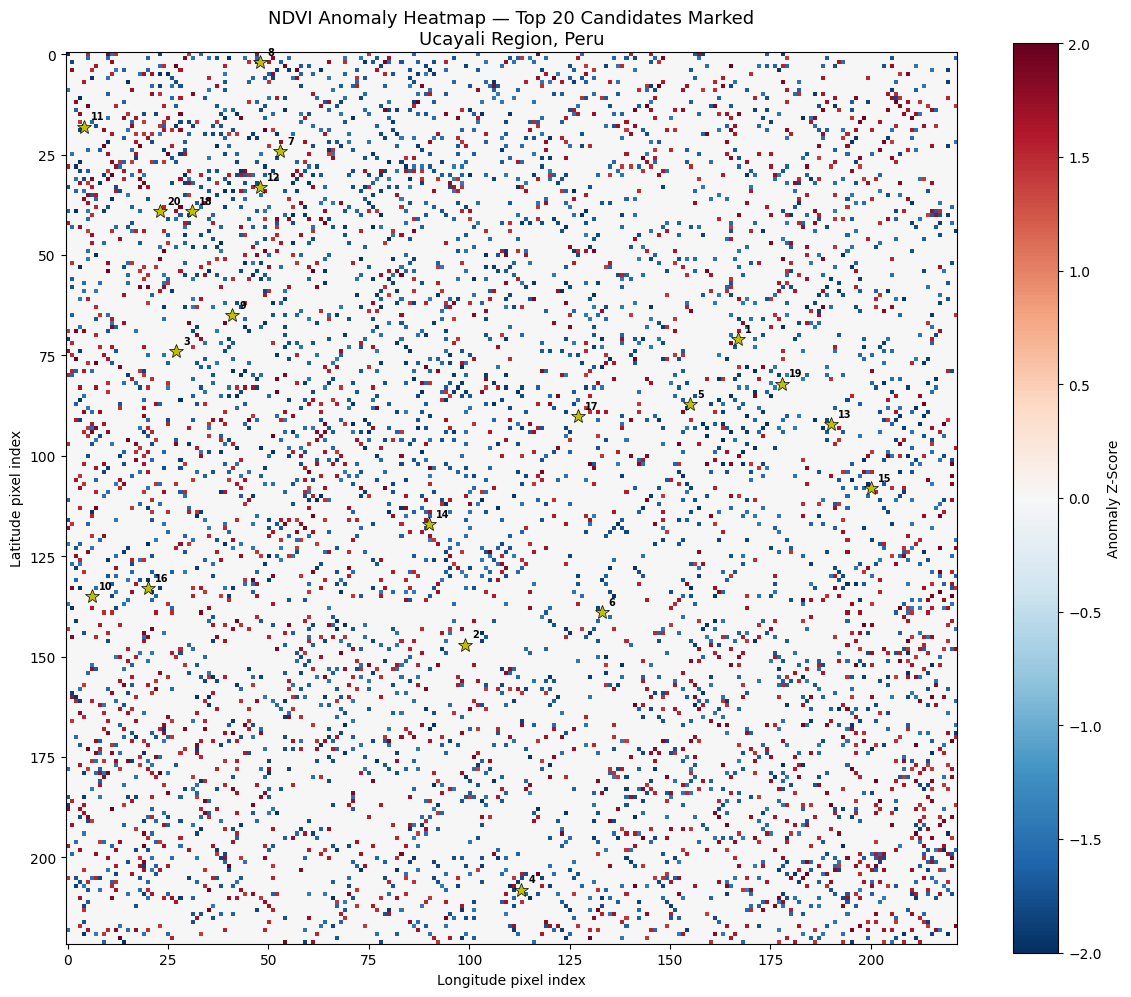

Saved as final_candidates.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 10))

# base heatmap
threshold = 1.4
z_filtered = np.array([v if abs(v) > threshold else 0 for v in z_list[:side*side]])
z_filtered_2d = z_filtered.reshape(side, side)

img_plot = ax.imshow(
    z_filtered_2d,
    cmap='RdBu_r',
    vmin=-2,
    vmax=2,
    interpolation='nearest'
)
plt.colorbar(img_plot, ax=ax, label='Anomaly Z-Score')

# plot top 20 candidate
for rank, (idx, val) in enumerate(top_candidates[:20], 1):
    row = idx // grid_side
    col = idx % grid_side
    ax.plot(col, row, 'y*', markersize=10, markeredgecolor='black', markeredgewidth=0.5)
    ax.annotate(str(rank), (col, row), textcoords="offset points",
                xytext=(5, 5), fontsize=7, color='black', fontweight='bold')

ax.set_title('NDVI Anomaly Heatmap — Top 20 Candidates Marked\nUcayali Region, Peru', fontsize=13)
ax.set_xlabel('Longitude pixel index')
ax.set_ylabel('Latitude pixel index')
plt.tight_layout()
plt.savefig('final_candidates.png', dpi=150)
plt.show()
print("Saved as final_candidates.png")

In [17]:
import csv

with open('candidate_sites.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['rank', 'latitude', 'longitude', 'z_score'])
    for rank, (lat, lon, val) in enumerate(candidate_coords, 1):
        writer.writerow([rank, round(lat, 4), round(lon, 4), round(val, 3)])

print("Saved candidate_sites.csv")

Saved candidate_sites.csv


## Results Summary

**Pipeline**: NDVI z-score anomaly detection on Sentinel-2 imagery
**Region**: Ucayali, Peru (-75.5 to -74.5 lon, -8.5 to -7.5 lat)
**Total pixels sampled**: 49,284

**Anomalies flagged (|z| > 1.4)**:

Rank   Pixel Index    Z-Score   
------------------------------
1      15929          -1.998    
2      32733          -1.998    
3      16455          -1.997    
4      46289          1.996     
5      19469          -1.996    
6      30991          -1.995    
7      5381           -1.995    
8      492            -1.994    
9      14471          -1.994    
10     29976          -1.994    
11     4000           -1.993    
12     7374           -1.993    
13     20614          -1.993    
14     26064          1.992     
15     24176          -1.992    
16     29546          -1.992    
17     20107          -1.991    
18     8689           -1.991    
19     18382          -1.991    
20     8681           -1.990

**Top candidates identified**: 20

**Output files**: final_candidates.png, candidate_sites.csv

**Next step**: Cross-reference candidate coordinates against
known archaeological databases and run same pipeline on
Khentii range, Mongolia for Genghis Khan tomb region.